In [1]:
!pip install -qq ipywidgets
!apt-get install -qq -y graphviz graphviz-dev && pip install -qq pydot
!pip install -qq pygraphviz

Selecting previously unselected package libatk1.0-data.
(Reading database ... 120968 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...
Unpacking libatk1.0-data (2.36.0-3build1) ...
Selecting previously unselected package libatk1.0-0:amd64.
Preparing to unpack .../01-libatk1.0-0_2.36.0-3build1_amd64.deb ...
Unpacking libatk1.0-0:amd64 (2.36.0-3build1) ...
Selecting previously unselected package libgtk2.0-common.
Preparing to unpack .../02-libgtk2.0-common_2.24.33-2ubuntu2.1_all.deb ...
Unpacking libgtk2.0-common (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libxcomposite1:amd64.
Preparing to unpack .../03-libxcomposite1_1%3a0.4.5-1build2_amd64.deb ...
Unpacking libxcomposite1:amd64 (1:0.4.5-1build2) ...
Selecting previously unselected package libgtk2.0-0:amd64.
Preparing to unpack .../04-libgtk2.0-0_2.24.33-2ubuntu2.1_amd64.deb ...
Unpacking libgtk2.0-0:amd64 (2.24.33-2ubuntu2.1) ...
Selecting previously u

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [3]:
# os.environ["KERAS_BACKEND"] = "tensorflow"

In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

import sklearn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, PredictionErrorDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
## -- keras library --
import tensorflow as tf
from tensorflow.keras.utils import FeatureSpace
from tensorflow.keras.utils import plot_model

import warnings
warnings.simplefilter('ignore')
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings("ignore", message="Setting the random state for TF")

2026-05-27 11:54:58.863544: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779882899.114667      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779882899.192855      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779882899.761384      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779882899.761433      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779882899.761437      16 computation_placer.cc:177] computation placer alr

In [5]:
## -- Global Settings --

# sklearn.set_config(transform_output="pandas")

## -- Set Global Seed --
class CFG():
    SEED   = 42
    GREEN  = '\033[32m'
    YELLOW = '\033[33m'
    RESET  = '\033[0m'

tf.keras.utils.set_random_seed(CFG.SEED)

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    "figure.facecolor": '#0f0f1a', # Outer panel (stage)
    "axes.facecolor":   '#1a1a2e', # Inner panel (plot)
    "axes.edgecolor":   '#444466',
    "axes.labelcolor":  '#e0e0ff',
    "text.color":       'lightblue',
    "xtick.color":      '#e0e0ff',
    "ytick.color":      '#e0e0ff',
    "grid.color":       '#2a2a4a',
    "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

print(f"CLASSIC {CFG.GREEN} GREEN {CFG.RESET} {CFG.YELLOW} YELLOW {CFG.RESET}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e5/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
    test = pd.read_csv(PATH+"test.csv").drop(columns=['id'])
    ORIG_PATH = '/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/'
    orig = pd.read_csv(ORIG_PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e5 | F1 Pits Stop/_f1_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop(columns=['id'])
    test = pd.read_csv(PATH+'test.csv').drop(columns=['id'])
    orig = pd.read_csv(PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]

CATS = [c for c in test.columns if test[c].dtype in ['str', 'object', 'category']]
NUMS = [c for c in test.columns if c not in CATS+[TARGET]]
BASE = NUMS + CATS

orig = orig[train.columns]

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(NUMS)}")
print(f"Total Cats: {len(CATS)}")
print(f"Total Base: {len(BASE)}")

train[TARGET] = train[TARGET].astype(int)
orig[TARGET] = orig[TARGET].astype(int)

train_main = train.copy() # Save main default experimenting

Train shape: (439140, 15)
Test shape: (188165, 14)
Original shape: (101371, 15)

Total Nums: 11
Total Cats: 3
Total Base: 14


In [7]:
exclude_ = [c for c in orig['Race'].unique() if c not in train['Race'].unique()]
print('Varibale differences in Race feature:', exclude_)

orig[orig['Race'].isin(exclude_)].groupby(['Race'])[TARGET].size()

Varibale differences in Race feature: ['Pre-Season Test', 'Pre-Season Track Session']


Race
Pre-Season Test             918
Pre-Season Track Session    773
Name: PitNextLap, dtype: int64

In [8]:
# ## -- Fix differences --
# orig['Race'].replace(exclude_, 'Pre-Season Testing', inplace=True)
# orig['Compound'].fillna(orig['Compound'].mode()[0], inplace=True)

In [9]:
display(train.head())
train.info()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [10]:
train.describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


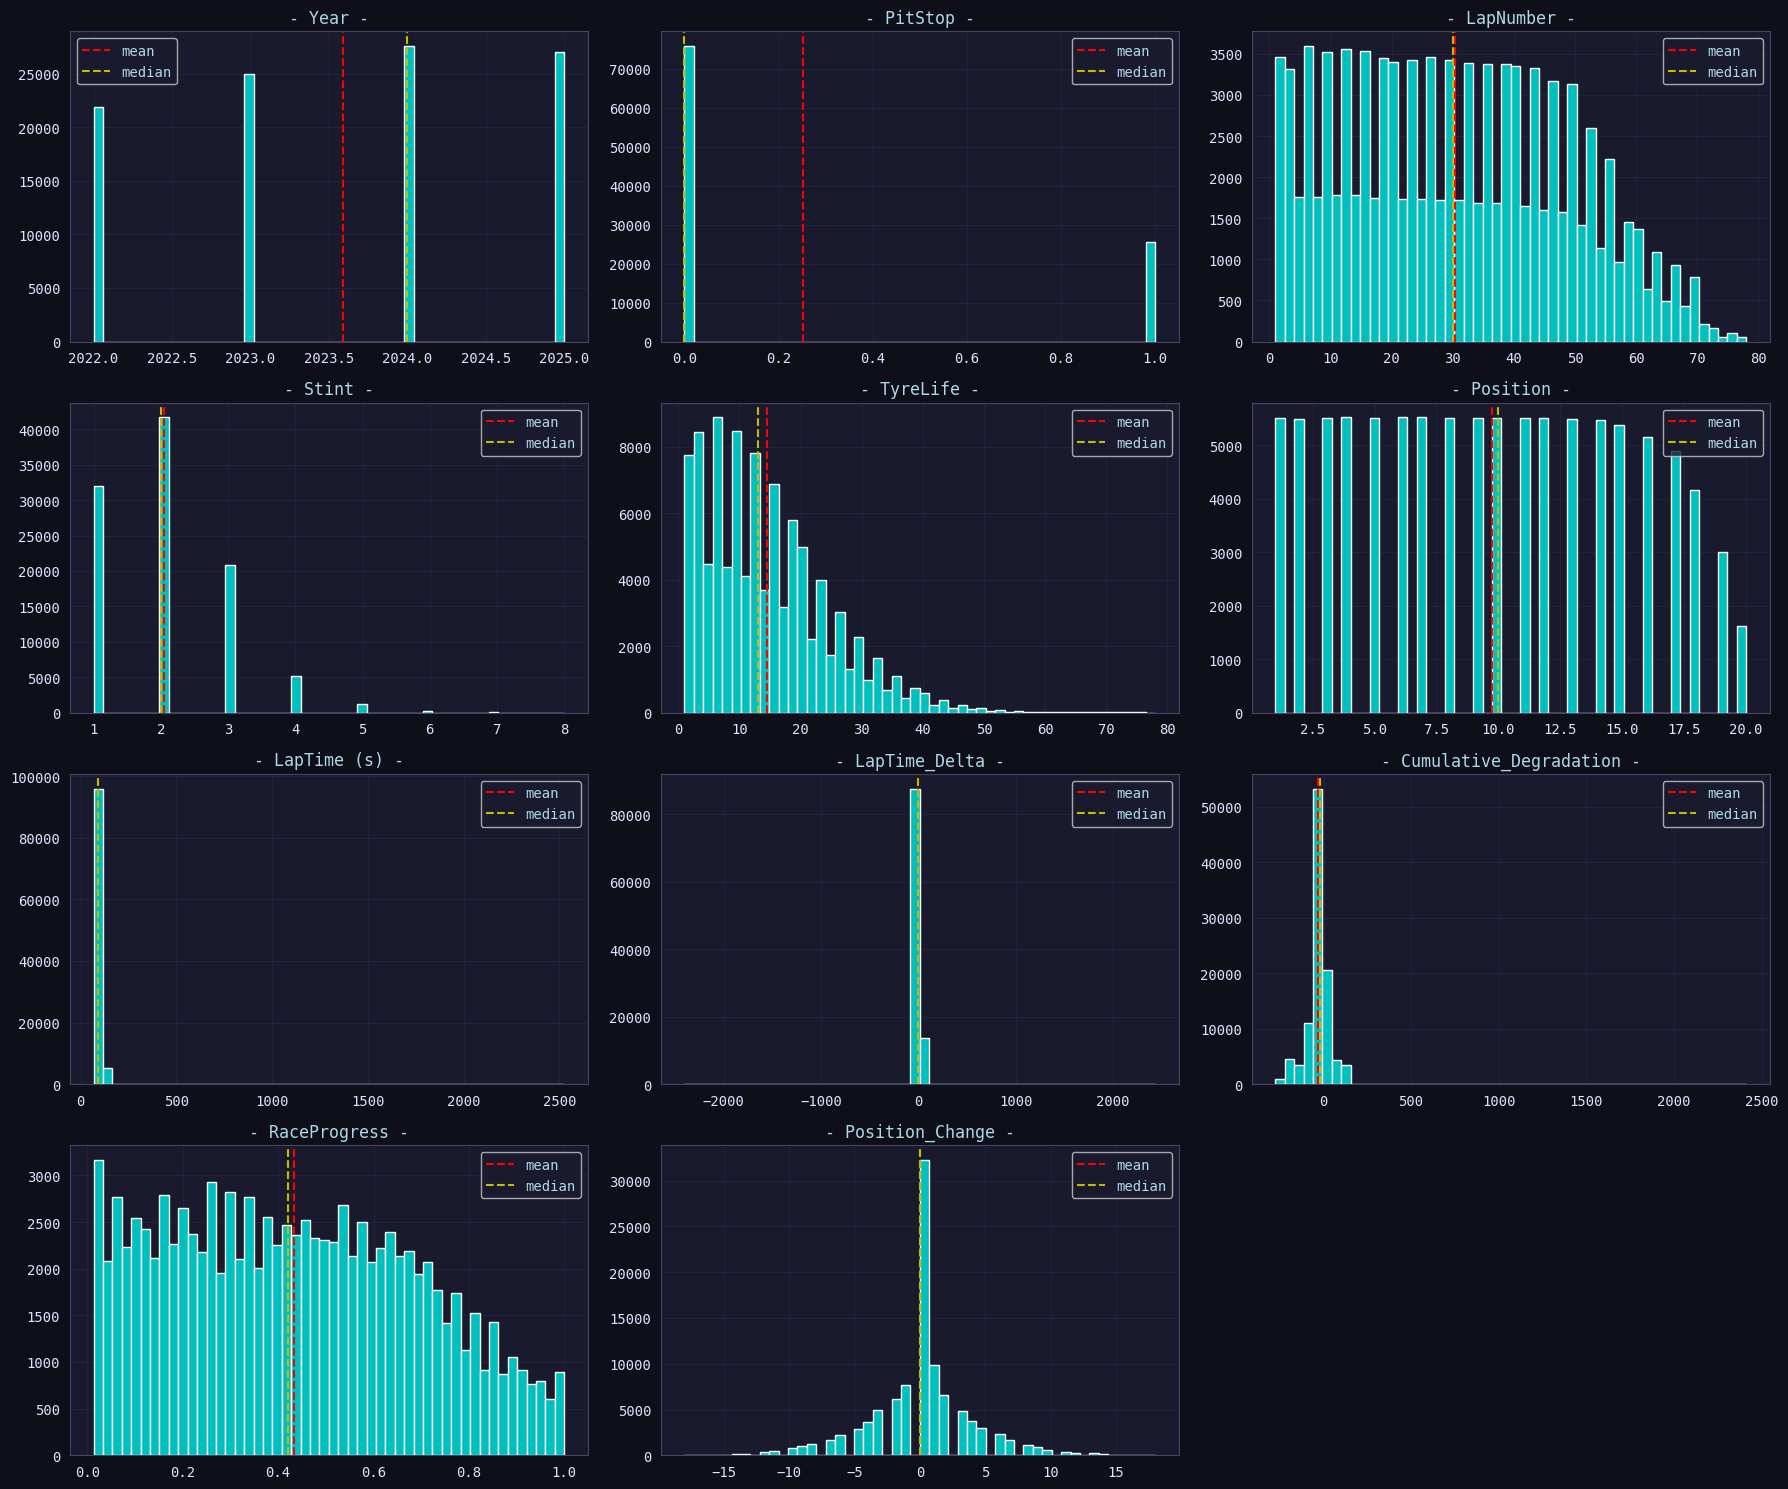

In [11]:
plt.figure(figsize=(18, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [12]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Driver,Compound,Race
Train,4,2,78,8,78,20,37719,57532,142701,1898,37,887,5,26
Original,4,2,78,8,78,20,40779,54084,81360,1437,37,31,5,28
Test,4,2,77,8,77,20,30286,40673,86823,1556,37,801,5,26


In [13]:
n_unique = train[BASE].nunique().sort_values()
n_unique

PitStop                        2
Year                           4
Compound                       5
Stint                          8
Position                      20
Race                          26
Position_Change               37
LapNumber                     78
TyreLife                      78
Driver                       887
RaceProgress                1898
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
dtype: int64

In [14]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return class_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return class_weights

print('- Helper Functions Ready -')

- Helper Functions Ready -


## FEATURE ENGINEERING

In [15]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [16]:
# _extract_cols = ['Cumulative_Degradation', 'LapTime (s)', 'LapTime_Delta'] # 'LapTime_Delta'

# for col in _extract_cols:
#     print(f"\nRounding... ", end='')
#     for r in [-2, -1, 0, 1, 2]:
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')

#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in [-3, -2, -1, 0, 1, 2, 3]:
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [17]:
# print(f"\nRounding... ", end='')
# for col in ['LapTime (s)']:
#     for r in [-2, -1, 0, 1, 2]:
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in [0, 1, 2, 3, 4, 5, 6]:
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [5]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [18]:
# train = train.drop(columns=DROP_COLS)
# test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

# print(f"Features dropped: {DROP_COLS}")

In [19]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [20]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [21]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreating frequencies... ", end='')
# for col in CATS: #  + ['LapNumber', 'RaceProgress'] 'Position_Change'
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'_{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print(f"\n✓ Total frequency features: {len(freq_cols)}")

In [22]:
# INTER = []
# top_cols = ['Year', 'Compound', 'Stint', 'Race', 'PitStop', 'Driver'] 
# low_cols = ['Driver', 'Position', 'Position_Change', 'LapNumber', 'TyreLife']

# for c1, c2 in tqdm(list(itertools.combinations(top_cols, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

In [23]:
## -- Arithmetic interactions --
for df in [train, test, orig]:
    df['_LapNum_div_RaceProgress'] = (df['LapNumber'] / (df['RaceProgress'] + 1e-6)).astype('float32')
    df['_TyreLife_div_LapNum'] = (df['TyreLife'] / df['LapNumber'].clip(lower=1)).astype('float32')
    df['_lapTime_s_*_Cum_Deg'] = (df['LapTime (s)'] * df['Cumulative_Degradation']).astype('float32')
    df['_LapTime_s_*_Cum_Deg_abs'] = (df['LapTime (s)'] * df['Cumulative_Degradation'].abs()).astype('float32')
    df['_LapTime_s_div_Cum_Deg_abs'] = (df['LapTime (s)'] / (df['Cumulative_Degradation'].abs() + 1e-6)).astype('float32')

arithmetic = [
    '_LapNum_div_RaceProgress',
    '_TyreLife_div_LapNum',
    '_lapTime_s_*_Cum_Deg',
    '_LapTime_s_*_Cum_Deg_abs',
    '_LapTime_s_div_Cum_Deg_abs',
]

print(f"Total Arithmetic interactions: {len(arithmetic)}")
train[arithmetic].head()

Total Arithmetic interactions: 5


,_LapNum_div_RaceProgress,_TyreLife_div_LapNum,_lapTime_s_*_Cum_Deg,_LapTime_s_*_Cum_Deg_abs,_LapTime_s_div_Cum_Deg_abs
0,69.999901,0.780000,1649.802368,1649.802368,3.734288
1,77.999771,0.259259,-16761.730469,16761.730469,0.336437
2,71.999908,0.372881,-7132.029785,7132.029785,0.705717
3,25.999662,1.000000,-691.099976,691.099976,12.883805
4,71.999802,0.230769,-1525.286987,1525.286987,7.629817


In [24]:
# ## -- Cyclic encoding --
# CYCLICS = []

# for col in ['MonthlyCharges', 'TotalCharges']:
#     for p in [12, 30]:
#         n_s = f'{col}_sin_{p}'
#         n_c = f'{col}_cos_{p}'
#         train[n_s] = np.sin(2 * np.pi * train[col] / p).astype('float32')
#         train[n_c] = np.cos(2 * np.pi * train[col] / p).astype('float32')

#         test[n_s] = np.sin(2 * np.pi * test[col] / p).astype('float32')
#         test[n_c] = np.cos(2 * np.pi * test[col] / p).astype('float32')

#         orig[n_s] = np.sin(2 * np.pi * orig[col] / p).astype('float32')
#         orig[n_c] = np.cos(2 * np.pi * orig[col] / p).astype('float32')

#         CYCLICS += [n_s, n_c]

# print(f"Cylcic Features created: {len(CYCLICS)}")
# train[CYCLICS].head(3)

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [26]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [27]:
# ## -- Apply log transformation --
# for df in [train, test, orig]:
#     df['_log_RaceProgress'] = np.log(df['RaceProgress'])
#     df['_log_LapTime_s'] = np.log(df['LapTime (s)'])

# log_features = ['_log_RaceProgress', '_log_LapTime_s']

# # ## -- Absolute values --
# # for df in [train, test, orig]:
# #     df['abs_lap_delta'] = np.abs(df['LapTime_Delta'])
# #     df['abs_degrade'] = np.abs(df['Cumulative_Degradation'])

# # abs_features = ['abs_lap_delta', 'abs_degrade']

# # plt.figure(figsize=(18, 8))
# # for i, col in enumerate(log_features+abs_features):
# #     plt.subplot(2, 2, i+1)
# #     plt.hist(train[col], bins=50)
# #     # orig[col].plot.hist()
# #     plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
# #     plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
# #     plt.title(f'{col}')
# #     plt.legend()

# # plt.tight_layout()
# # plt.show()

In [28]:
# ## -- Lag/Differential features --
# # ['Delta_lag1', 'Delta_roll3_mean', 'Deg_diff', 'TyreLife_growth', 'LapTime_lag1', 'LapTime_diff']

# for df in [train, test, orig]:
#     df['Degrade_diff'] = df['Cumulative_Degradation'].diff()
#     df['LapTime_diff'] = df['LapTime (s)'].diff()
#     df['Delta_roll_3'] = df['LapTime_Delta'].rolling(3).mean()
#     # df['Delta_roll_3_LapNum'] = df['LapTime_Delta'].rolling(3).mean()
#     df['LapTime_delta_shift'] = df['LapTime (s)'].shift(3) #'infer, 'D'
    
# lag_features = [
#     'Degrade_diff',
#     'LapTime_diff',
#     'Delta_roll_3',
#     # 'Delta_roll_3_LapNum',
#     'LapTime_delta_shift'
# ]

# train[lag_features].describe()
# # train.head()

In [29]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE+ROUNDS, #+DIGITS, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

In [30]:
# ## -- Factorize using combined data --
# for c in ['Driver']:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[-len(orig):]

# print('Label encoding complete!')

In [31]:
# ## -- Flag 'Year' == 2023 --
# for df in [train, test, orig]:
#     df['_is_2023'] = (df['Year'] == 2023).astype('int8')

# print('Flag Year:', '_is_2023')

In [32]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head()

Total Features: 19


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,_LapNum_div_RaceProgress,_TyreLife_div_LapNum,_lapTime_s_*_Cum_Deg,_LapTime_s_*_Cum_Deg_abs,_LapTime_s_div_Cum_Deg_abs
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1,69.999901,0.780000,1649.802368,1649.802368,3.734288
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0,77.999771,0.259259,-16761.730469,16761.730469,0.336437
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1,71.999908,0.372881,-7132.029785,7132.029785,0.705717
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0,25.999662,1.000000,-691.099976,691.099976,12.883805
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0,71.999802,0.230769,-1525.286987,1525.286987,7.629817


In [33]:
## -- Ohe-Hot encode categories --
OHE_CATS = ['Compound', 'Race'] + ['Year', 'Stint']

combined = pd.concat([train[FEATURES], test[FEATURES], orig[FEATURES]])
combined_ohe = pd.get_dummies(combined, columns=OHE_CATS, dtype='int64', drop_first=False)

train_enc = combined_ohe[:len(train)]
test      = combined_ohe[len(train):len(train)+len(test)]
orig_enc  = combined_ohe[len(train)+len(test):]

train = pd.concat([train_enc, train[TARGET]], axis=1)
orig  = pd.concat([orig_enc, orig[TARGET]], axis=1)

print(f'One-Hot Encoding complete!\nExpanded Features: {combined_ohe.shape[1]}')

combined_ohe.head(3)

One-Hot Encoding complete!
Expanded Features: 60


,Driver,PitStop,LapNumber,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,_LapNum_div_RaceProgress,_TyreLife_div_LapNum,_lapTime_s_*_Cum_Deg,_LapTime_s_*_Cum_Deg_abs,_LapTime_s_div_Cum_Deg_abs,Compound_HARD,Compound_INTERMEDIATE,Compound_MEDIUM,Compound_SOFT,Compound_WET,Race_Abu Dhabi Grand Prix,Race_Australian Grand Prix,Race_Austrian Grand Prix,Race_Azerbaijan Grand Prix,Race_Bahrain Grand Prix,Race_Belgian Grand Prix,Race_British Grand Prix,Race_Canadian Grand Prix,Race_Chinese Grand Prix,Race_Dutch Grand Prix,Race_Emilia Romagna Grand Prix,Race_French Grand Prix,Race_Hungarian Grand Prix,Race_Italian Grand Prix,Race_Japanese Grand Prix,Race_Las Vegas Grand Prix,Race_Mexico City Grand Prix,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Test,Race_Pre-Season Testing,Race_Pre-Season Track Session,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix,Year_2022,Year_2023,Year_2024,Year_2025,Stint_1,Stint_2,Stint_3,Stint_4,Stint_5,Stint_6,Stint_7,Stint_8
0,D109,0,50,39.0,8,78.491,-7.564,21.019,0.714286,5.0,69.999901,0.780000,1649.802368,1649.802368,3.734288,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
1,D086,1,27,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,77.999771,0.259259,-16761.730469,16761.730469,0.336437,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
2,ZON,0,59,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,71.999908,0.372881,-7132.029785,7132.029785,0.705717,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0


In [34]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
NEW_CATS = [c for c in FEATURES if c.endswith('_')]
NEW_NUMS = [c for c in FEATURES if c.startswith('_')]

print('Total Features:', len(FEATURES))
print('Total new Cats:', len(NEW_CATS))
print('Total new Nums:', len(NEW_NUMS))

train.head(3)

Total Features: 60
Total new Cats: 0
Total new Nums: 5


,Driver,PitStop,LapNumber,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,_LapNum_div_RaceProgress,_TyreLife_div_LapNum,_lapTime_s_*_Cum_Deg,_LapTime_s_*_Cum_Deg_abs,_LapTime_s_div_Cum_Deg_abs,Compound_HARD,Compound_INTERMEDIATE,Compound_MEDIUM,Compound_SOFT,Compound_WET,Race_Abu Dhabi Grand Prix,Race_Australian Grand Prix,Race_Austrian Grand Prix,Race_Azerbaijan Grand Prix,Race_Bahrain Grand Prix,Race_Belgian Grand Prix,Race_British Grand Prix,Race_Canadian Grand Prix,Race_Chinese Grand Prix,Race_Dutch Grand Prix,Race_Emilia Romagna Grand Prix,Race_French Grand Prix,Race_Hungarian Grand Prix,Race_Italian Grand Prix,Race_Japanese Grand Prix,Race_Las Vegas Grand Prix,Race_Mexico City Grand Prix,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Test,Race_Pre-Season Testing,Race_Pre-Season Track Session,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix,Year_2022,Year_2023,Year_2024,Year_2025,Stint_1,Stint_2,Stint_3,Stint_4,Stint_5,Stint_6,Stint_7,Stint_8,PitNextLap
0,D109,0,50,39.0,8,78.491,-7.564,21.019,0.714286,5.0,69.999901,0.780000,1649.802368,1649.802368,3.734288,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1
1,D086,1,27,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,77.999771,0.259259,-16761.730469,16761.730469,0.336437,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0
2,ZON,0,59,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,71.999908,0.372881,-7132.029785,7132.029785,0.705717,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1


# ML TRAINING

In [35]:
try:
    from scikeras.wrappers import KerasClassifier
except:
    %pip install -q -U scikeras
    from scikeras.wrappers import KerasClassifier

!pip show scikeras

Note: you may need to restart the kernel to use updated packages.
Name: scikeras
Version: 0.13.0
Summary: Scikit-Learn API wrapper for Keras.
Home-page: https://github.com/adriangb/scikeras
Author: Adrian Garcia Badaracco
Author-email: 1755071+adriangb@users.noreply.github.com
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: keras, scikit-learn
Required-by: 


In [36]:
def build_keras_model(shape, units, act, drop):

    # 2. Create the Sequential model
    model = tf.keras.Sequential([
        tf.keras.Input(shape=shape),
        # Optional: Add BN here if your data isn't pre-scaled
        tf.keras.layers.BatchNormalization(),

        ## -- 1st Layer --
        tf.keras.layers.Dense(units[0], act), #use_bias=False,
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop),

        ## -- 2nd Layer --
        tf.keras.layers.Dense(units[1], act), #use_bias=False,
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop),

        ## -- 3rd Layer --
        tf.keras.layers.Dense(units[2], act), #use_bias=False,
        tf.keras.layers.BatchNormalization(),
        # keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop),

        ## -- Output --
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    # ## -- Compile model --
    # model.compile(
    #     # optimizer=tf.keras.optimizers.RMSprop(learning_rate),
    #     optimizer=tf.keras.optimizers.Adam(lr), # , weight_decay=None
    #     loss='binary_crossentropy',
    #     metrics=[tf.keras.metrics.AUC(name='auc')]
    # )

    return model

print('⚙️ KERAS MODEL READY ⚙️')

⚙️ KERAS MODEL READY ⚙️


In [37]:
# def build_keras_model(
#     feature_space: tf.keras.utils.FeatureSpace=None,
#     num_layers=3,
#     layer_units=128,
#     learning_rate=0.01,
#     dropout_rate=0.3,
#     l2_reg=0.0,
#     **kwargs
#     ):
#     # 1. Setup Inputs
#     dict_inputs = feature_space.get_inputs()

#     # 2. Build the MLP using Sequential for efficiency and readability
#     # We use the encoded features as the starting point
#     encoded_features = feature_space.get_encoded_features()

#     layers = []
#     kernel_reg = tf.keras.regularizers.l2(l2_reg) if l2_reg > 0.0 else None

#     for i in range(num_layers):
#         # Calculate dimension d for Dense layer: halves with each layer, minimum of 32 units
#         d = max(32, layer_units // (2**i))
#         layers.append(tf.keras.layers.Dense(units=d, 'relu', kernel_regularizer=kernel_reg))
#         layers.append(tf.keras.layers.BatchNormalization())
#         layers.append(tf.keras.layers.Dropout(dropout_rate))
#         # Increase dropout as layers get deeper/smaller -> dropout_rate+(i * 0.05)

#     # Final output layer
#     layers.append(tf.keras.layers.Dense(1, activation='sigmoid'))

#     # 3. Create the Sequential model for the "head"
#     mlp_head = tf.keras.Sequential(layers)

#     # 4. Connect everything
#     outputs = mlp_head(encoded_features)
#     train_model = tf.keras.Model(inputs=encoded_features, outputs=outputs)

#     # 5. Compile
#     train_model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
#         loss='binary_crossentropy',
#         metrics=[tf.keras.metrics.AUC(name='auc')]
#     )

#     infer_model = tf.keras.Model(inputs=dict_inputs, outputs=outputs)

#     return train_model, infer_model

# print('⚙️ SEQUENTIAL MODEL ⚙️')


In [38]:
## -- DEFINE TRAINER --
class TrainerCV:
    def __init__(
        self,
        model_builder, # function -> tf.keras.Model
        model_name: str,
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        features: list,
        target: str,
        kf,            # e.g., StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        learning_rate: float=0.01,
        layer_units: list=[256, 128, 64],
        drop_rate: float=0.2,
        batch_size: int=32,
        epochs: int=10,
        patience: int=3,
        activation: str='relu',
        eval_metric: str='auc',
        use_orig: bool=False,
        **kwargs
    ):
        self.model_builder = model_builder
        self.model_name = model_name
        self.train_df = train_df
        self.test_df = test_df
        self.features = features
        self.target = target
        self.kf = kf
        self.learning_rate = learning_rate
        self.units = layer_units
        self.drop_rate = drop_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.activation = activation
        self.eval_metric = eval_metric
        self.use_orig = use_orig
        
        self.result = None

        # Storage
        self.oof_preds   = np.zeros(len(train_df))
        self.test_preds  = np.zeros(len(test_df))
        self.fold_scores = []

    def _prepare_fold_data(self, X, y, X_val=None, y_valid=None):
        # This helper can be extended if you want to apply masks or augmentation.
        return X, y

    def fit(self):
        train_df = self.train_df
        test_df  = self.test_df
        features = self.features
        target   = self.target

        print(f"\n===== Starting Cross-Validation for {self.model_name} =====")
        start = time()

        self.oof_preds  = np.zeros(len(train_df))
        self.test_preds = np.zeros(len(test_df))
        self.oof_scores = []
        self.fold_histories = []

        X = train_df[features]
        y = train_df[target]

        strategy = tf.distribute.MirroredStrategy()
        GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
        print('⚙️ Number of devices: {}'.format(strategy.num_replicas_in_sync))

        for idx, (train_idx, val_idx) in enumerate(self.kf.split(X, y)):
            print(f"\n===== Fold {idx+1}/{self.kf.n_splits}", end='')

            X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
            X_test = test_df[features].copy()

            if self.use_orig:
                X_train = pd.concat([X_train, orig[features]]).fillna('unknown').reset_index(drop=True).copy()
                y_train = pd.concat([y_train, orig[target]]).reset_index(drop=True).copy()
                # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

            # ## -- TE Opt1. -> Using CUSTOM -- + ROUNDS
            # te_enc1 = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
            # X_train = te_enc1.fit_transform(X_train, y_train)
            # X_valid = te_enc1.transform(X_valid)
            # X_test  = te_enc1.transform(X_test)
    
            ## -- TE Opt1. -> Using CUSTOM --
            te_enc2 = TargetEncoder(['Driver'], cv=5, smooth='auto', aggs=['mean'], drop_original=True)
            X_train = te_enc2.fit_transform(X_train, y_train)
            X_valid = te_enc2.transform(X_valid)
            X_test  = te_enc2.transform(X_test)

            ## -- Define callbacks --
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                    patience=self.patience,
                    restore_best_weights=True,
                ),
                # tf.keras.callbacks.ReduceLROnPlateau(
                #     monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                #     factor=0.5,
                #     patience=5,
                #     min_lr=1e-6,
                #     verbose=1
                # ),
                tf.keras.callbacks.ModelCheckpoint( # -> save model
                    filepath=f"{CHECKPOINT}best_model.model.keras",
                    monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                    save_best_only=True,
                    # verbose=1
                ),
                tf.keras.callbacks.ModelCheckpoint( # -> save weights
                    filepath=f"{CHECKPOINT}best_model.weights.h5",
                    monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                    save_best_only=True,
                    save_weights_only=True,
                ),
            ]

            ## -- Build model --
            keras_clf = KerasClassifier(
                self.model_builder,
                model__shape=X_train.shape[1:],
                model__units=self.units,
                model__act=self.activation,
                model__drop=self.drop_rate,
                # optimizer=tf.keras.optimizers.RMSprop(self.learning_rate),
                optimizer=tf.keras.optimizers.Adam(self.learning_rate), # , weight_decay=None
                loss='binary_crossentropy',
                metrics=[tf.keras.metrics.AUC(name=self.eval_metric)],
                epochs=self.epochs,
                batch_size=GLOBAL_BATCH_SIZE,
                # validation_batch_size=10000,
                # fit__batch_size=GLOBAL_BATCH_SIZE,
                # predict__batch_size=10000,
                verbose=2,
                callbacks=callbacks,
                shuffle=True,
                run_eagerly=False,
                random_state=CFG.SEED,
                # class_weight=get_weights(y_train, y_train),
            )

            print(f' • Training model {X_train.shape}... ')
            keras_clf.fit(X_train, y_train, validation_data=(X_valid, y_valid))
            # sample_weight=get_weights(y_train, y_train)

            self.fold_histories.append(keras_clf.history_)

            ## -- Make predictions --
            self.oof_preds[val_idx] = keras_clf.predict_proba(X_valid)[:, 1]
            self.test_preds += keras_clf.predict_proba(X_test)[:, 1]
            fold_auc = roc_auc_score(y_valid, self.oof_preds[val_idx])
            self.oof_scores.append(fold_auc)
            print(f'{CFG.YELLOW} • Fold {idx+1} AUC: {fold_auc:.5f}{CFG.RESET}')

        self.test_preds /= self.kf.n_splits

        ## -- Print final cross-validation results --
        print("\n==================================================")
        print(f"Cross-Validation Results for {self.model_name}")
        print("==================================================")
        for i, score in enumerate(self.oof_scores):
            print(f" • Fold {i+1} auc: {score:.5f}")

        overall_AUC  = np.round(roc_auc_score(y, self.oof_preds), 5)
        avg_fold_AUC = np.round(np.mean(self.oof_scores), 5)
        std_fold_AUC = np.round(np.std(self.oof_scores), 5)

        print("-------------------------------------------------|")
        print(f"Overall score: {overall_AUC}")
        print(f"Average score: {avg_fold_AUC} ± {std_fold_AUC}")
        print("-------------------------------------------------|")
        print(f'{((time() - start) / 60):.2f} mins\n')

        return {
            'oof_preds': self.oof_preds,
            'test_preds': self.test_preds,
            'fold_score': self.oof_scores,
            'avg_score': avg_fold_AUC,
            'final_score': overall_AUC,
            'val_data': [X_valid, y_valid],
            'history': self.fold_histories,
        }

print('⚙️ KERAS TRAINER READY ⚙️')

⚙️ KERAS TRAINER READY ⚙️


In [39]:
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
x_sample.head(3)

,Driver,PitStop,LapNumber,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,_LapNum_div_RaceProgress,_TyreLife_div_LapNum,_lapTime_s_*_Cum_Deg,_LapTime_s_*_Cum_Deg_abs,_LapTime_s_div_Cum_Deg_abs,Compound_HARD,Compound_INTERMEDIATE,Compound_MEDIUM,Compound_SOFT,Compound_WET,Race_Abu Dhabi Grand Prix,Race_Australian Grand Prix,Race_Austrian Grand Prix,Race_Azerbaijan Grand Prix,Race_Bahrain Grand Prix,Race_Belgian Grand Prix,Race_British Grand Prix,Race_Canadian Grand Prix,Race_Chinese Grand Prix,Race_Dutch Grand Prix,Race_Emilia Romagna Grand Prix,Race_French Grand Prix,Race_Hungarian Grand Prix,Race_Italian Grand Prix,Race_Japanese Grand Prix,Race_Las Vegas Grand Prix,Race_Mexico City Grand Prix,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Test,Race_Pre-Season Testing,Race_Pre-Season Track Session,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix,Year_2022,Year_2023,Year_2024,Year_2025,Stint_1,Stint_2,Stint_3,Stint_4,Stint_5,Stint_6,Stint_7,Stint_8,PitNextLap
55143,D207,0,3,6.0,18,81.919,-0.780,-22.988,0.052632,3.0,56.998917,2.000000,-1883.153931,1883.153931,3.563555,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0
157283,D193,0,9,9.0,3,84.336,0.163,-3.077,0.126761,0.0,70.999443,1.000000,-259.501862,259.501862,27.408506,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
203881,D046,1,24,17.0,9,81.790,-13.936,-91.095,0.311688,8.0,76.999756,0.708333,-7450.660156,7450.660156,0.897854,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0


In [40]:
!rm -r {CHECKPOINT}

rm: cannot remove '{CHECKPOINT}': No such file or directory


In [41]:
if PLATFORM == 'kaggle':
    CHECKPOINT = '/kaggle/working/checkpoints/'
elif PLATFORM == 'colab':
    CHECKPOINT = '/content/checkpoints'

!mkdir {CHECKPOINT}

print(f"☑️ Checkpoint directory: {CHECKPOINT}")

☑️ Checkpoint directory: /kaggle/working/checkpoints/


In [42]:
np.array([256, 128, 64], dtype=np.int64)

array([256, 128,  64])

In [43]:
%%time

version_name = 'scikeras_orig_'

FOLDS       = 5
LR          = 0.002
EPOCHS      = 50
PATIENCE    = 5
BATCH_SIZE  = 64
DROP_RATE   = 0.3
LAYER_UNITS = [256, 128, 64]

USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

trainer = TrainerCV(
    model_builder=build_keras_model,
    model_name=version_name,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=CFG.SEED),
    learning_rate=LR,
    layer_units=LAYER_UNITS ,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    patience=PATIENCE,
    drop_rate=DROP_RATE,
    activation='relu',
    eval_metric='auc',
    use_orig=True,
)

result = trainer.fit()


===== Starting Cross-Validation for scikeras_orig_ =====
⚙️ Number of devices: 1

===== Fold 1/5

2026-05-27 11:55:30.320200: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


 • Training model (452683, 60)... 
Epoch 1/50


2026-05-27 11:55:33.526623: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-05-27 11:56:01.440269: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

7074/7074 - 31s - 4ms/step - auc: 0.9138 - loss: 0.2944 - val_auc: 0.9366 - val_loss: 0.2492
Epoch 2/50
7074/7074 - 27s - 4ms/step - auc: 0.9266 - loss: 0.2732 - val_auc: 0.9378 - val_loss: 0.2470
Epoch 3/50
7074/7074 - 27s - 4ms/step - auc: 0.9302 - loss: 0.2671 - val_auc: 0.9399 - val_loss: 0.2427
Epoch 4/50
7074/7074 - 27s - 4ms/step - auc: 0.9323 - loss: 0.2631 - val_auc: 0.9404 - val_loss: 0.2423
Epoch 5/50
7074/7074 - 28s - 4ms/step - auc: 0.9341 - loss: 0.2600 - val_auc: 0.9413 - val_loss: 0.2406
Epoch 6/50
7074/7074 - 27s - 4ms/step - auc: 0.9351 - loss: 0.2580 - val_auc: 0.9412 - val_loss: 0.2403
Epoch 7/50
7074/7074 - 27s - 4ms/step - auc: 0.9363 - loss: 0.2560 - val_auc: 0.9412 - val_loss: 0.2412
Epoch 8/50
7074/7074 - 27s - 4ms/step - auc: 0.9369 - loss: 0.2547 - val_auc: 0.9422 - val_loss: 0.2389
Epoch 9/50
7074/7074 - 27s - 4ms/step - auc: 0.9379 - loss: 0.2530 - val_auc: 0.9418 - val_loss: 0.2392
Epoch 10/50
7074/7074 - 27s - 4ms/step - auc: 0.9385 - loss: 0.2517 - val_a

...

1373/1373 - 2s - 2ms/step
2941/2941 - 4s - 1ms/step
 • Fold 4 AUC: 0.94322

===== Fold 5/5 • Training model (452683, 60)... 
Epoch 1/50


2026-05-27 12:41:17.870271: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-05-27 12:41:46.882841: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

7074/7074 - 32s - 5ms/step - auc: 0.9137 - loss: 0.2945 - val_auc: 0.9344 - val_loss: 0.2519
Epoch 2/50
7074/7074 - 29s - 4ms/step - auc: 0.9267 - loss: 0.2729 - val_auc: 0.9366 - val_loss: 0.2489
Epoch 3/50
7074/7074 - 29s - 4ms/step - auc: 0.9302 - loss: 0.2672 - val_auc: 0.9381 - val_loss: 0.2463
Epoch 4/50
7074/7074 - 28s - 4ms/step - auc: 0.9326 - loss: 0.2626 - val_auc: 0.9399 - val_loss: 0.2422
Epoch 5/50
7074/7074 - 28s - 4ms/step - auc: 0.9340 - loss: 0.2602 - val_auc: 0.9391 - val_loss: 0.2444
Epoch 6/50
7074/7074 - 28s - 4ms/step - auc: 0.9354 - loss: 0.2577 - val_auc: 0.9404 - val_loss: 0.2417
Epoch 7/50
7074/7074 - 28s - 4ms/step - auc: 0.9363 - loss: 0.2561 - val_auc: 0.9404 - val_loss: 0.2417
Epoch 8/50
7074/7074 - 28s - 4ms/step - auc: 0.9372 - loss: 0.2543 - val_auc: 0.9407 - val_loss: 0.2406
Epoch 9/50
7074/7074 - 28s - 4ms/step - auc: 0.9377 - loss: 0.2534 - val_auc: 0.9415 - val_loss: 0.2392
Epoch 10/50
7074/7074 - 28s - 4ms/step - auc: 0.9384 - loss: 0.2520 - val_a

2026-05-27 12:52:31.035606: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1373/1373 - 2s - 2ms/step
2941/2941 - 5s - 2ms/step
 • Fold 5 AUC: 0.94261

Cross-Validation Results for scikeras_orig_
 • Fold 1 auc: 0.94297
 • Fold 2 auc: 0.94126
 • Fold 3 auc: 0.94277
 • Fold 4 auc: 0.94322
 • Fold 5 auc: 0.94261
-------------------------------------------------|
Overall score: 0.94244
Average score: 0.94257 ± 0.00068
-------------------------------------------------|
57.16 mins

CPU times: user 1h 41min 16s, sys: 9min 2s, total: 1h 50min 18s
Wall time: 57min 10s


In [44]:
load_model = tf.keras.models.load_model(f"{CHECKPOINT}best_model.model.keras")
load_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_16          │ (None, 60)             │           240 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,565 (681.90 KB)

 Trainable params: 57,849 (225.97 KB)

 Non-trainable params: 1,016 (3.97 KB)

 Optimizer params: 115,700 (451.96 KB)

In [45]:
# ==================================================
# Cross-Validation Results for scikeras_v0_
# ==================================================
#  • Fold 1 auc: 0.93627
#  • Fold 2 auc: 0.93489
#  • Fold 3 auc: 0.93467
#  • Fold 4 auc: 0.93662
#  • Fold 5 auc: 0.93634
# -------------------------------------------------|
# Overall score: 0.93491
# Average score: 0.93576 ± 0.00081
# -------------------------------------------------|
# 13.45 mins

result['final_score'].item(), result['avg_score'].item()

(0.94244, 0.94257)

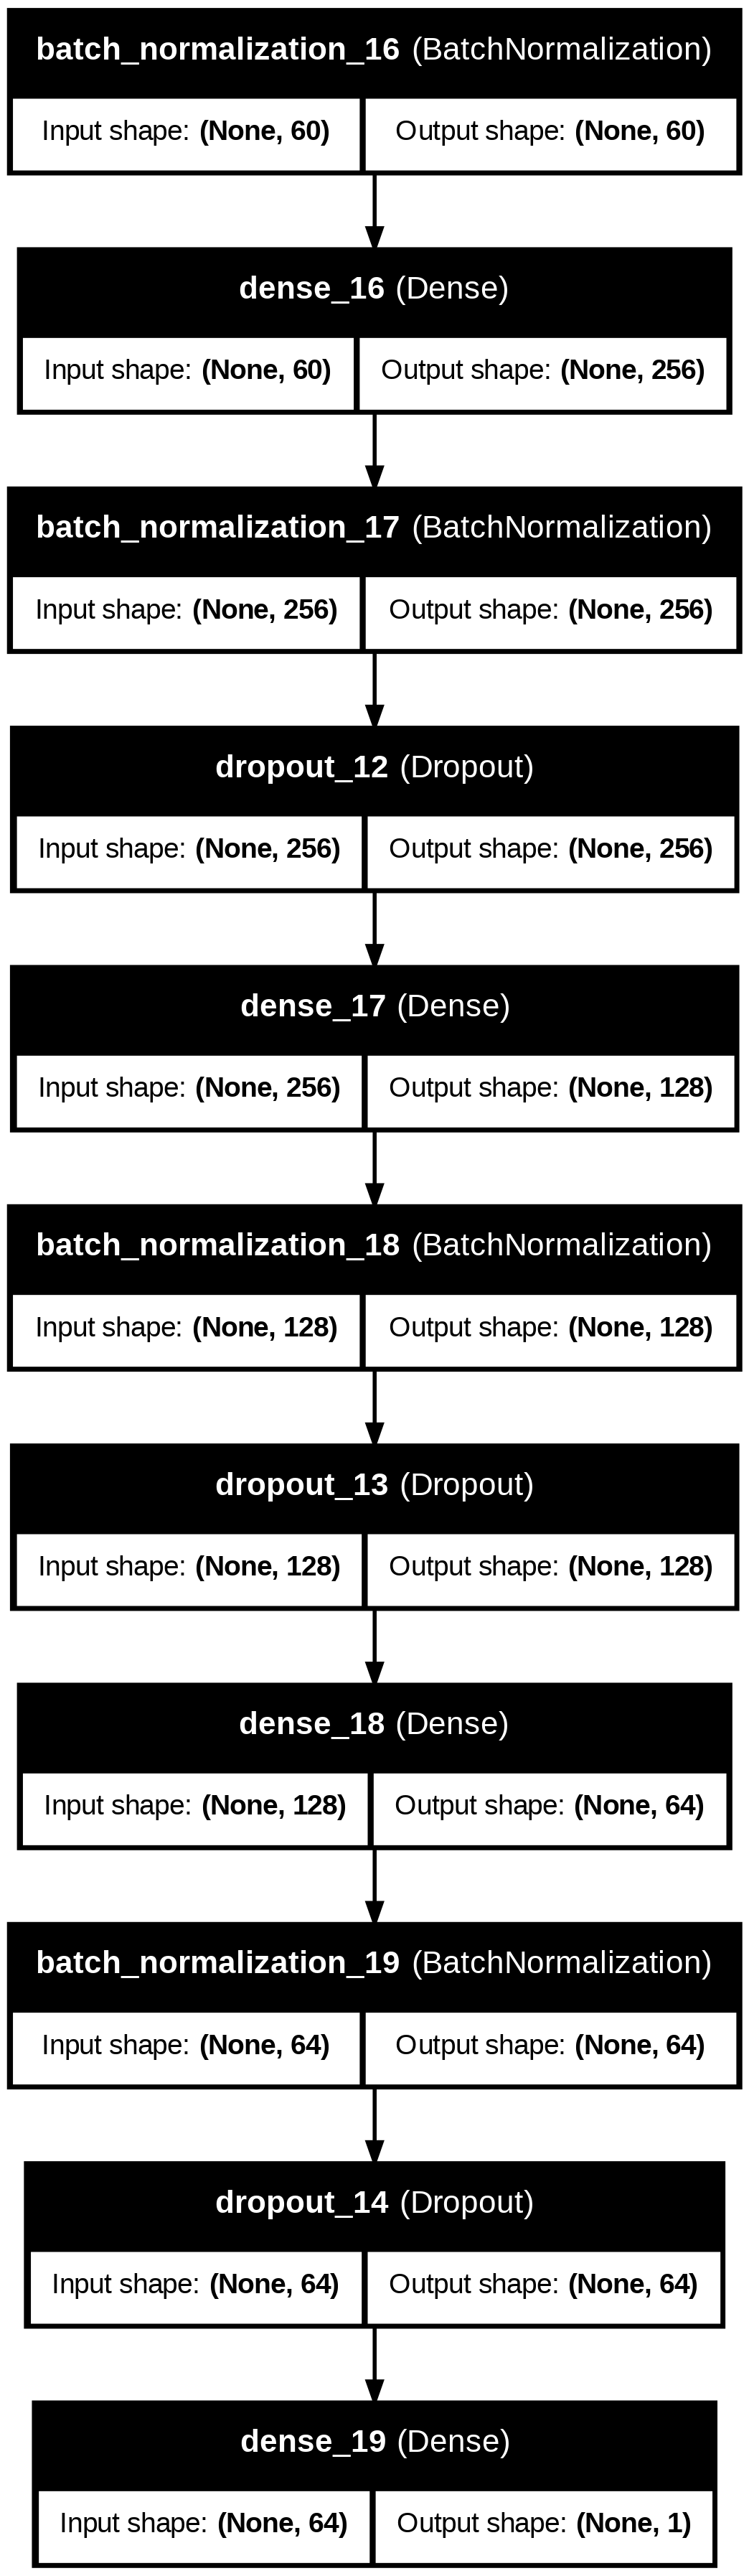

In [46]:
plot_model(
    load_model,
    rankdir='TB',
    show_layer_names=True,
    show_shapes=True,
    expand_nested=True,
    # show_dtype=True,
)

# display(Image('/kaggle/working/model.png'))

In [47]:
## -- Plot results --
def plot_results(history):
    for i in range(len(history)):
        loss_results = pd.DataFrame({'loss': history[i]['loss'], 'val_loss': history[i]['val_loss']})
        auc_results  = pd.DataFrame({'auc': history[i]['a_u_c'], 'val_auc': history[i]['val_auc']})
    
        plt.figure(figsize=(18, 6))
        marker = 'o'
    
        ## -- PLOT 1: LOSS --
        plt.subplot(121)
        sns.lineplot(loss_results, x=loss_results.index, y=loss_results['loss'], label='train', marker=marker)
        sns.lineplot(loss_results, x=loss_results.index, y=loss_results['val_loss'], label='valid', marker=marker)
        plt.title('LOSS', fontweight='semibold')
        plt.xlabel('epochs')
        plt.ylabel('auc')
    
        ## -- PLOT 2: ACCURACY --
        plt.subplot(122)
        sns.lineplot(auc_results, x=auc_results.index, y=auc_results['auc'], label='train', marker=marker)
        sns.lineplot(auc_results, x=auc_results.index, y=auc_results['val_auc'], label='valid', marker=marker)
        plt.title('AUC', fontweight='semibold')
        plt.xlabel('epochs')
        plt.ylabel('auc')

        stat_ = f"fold_score: {result['fold_score'][i]:.5f}"
        plt.scatter(x=0, y=0, label=stat_, color='y')
    
        plt.suptitle(f"- FOLD {i+1} -", fontsize=15, fontweight='semibold', color='y')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()
        print()

print('Plot function ready')

Plot function ready


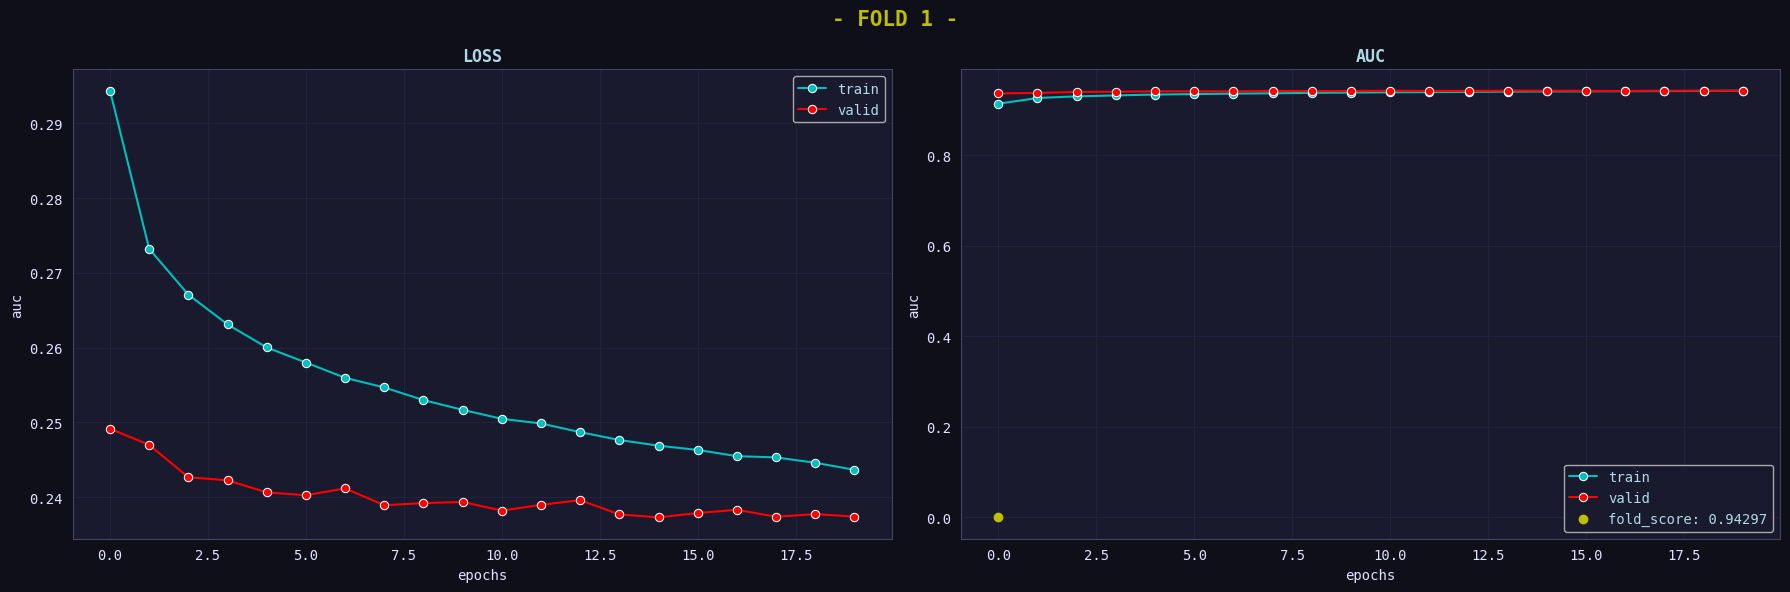

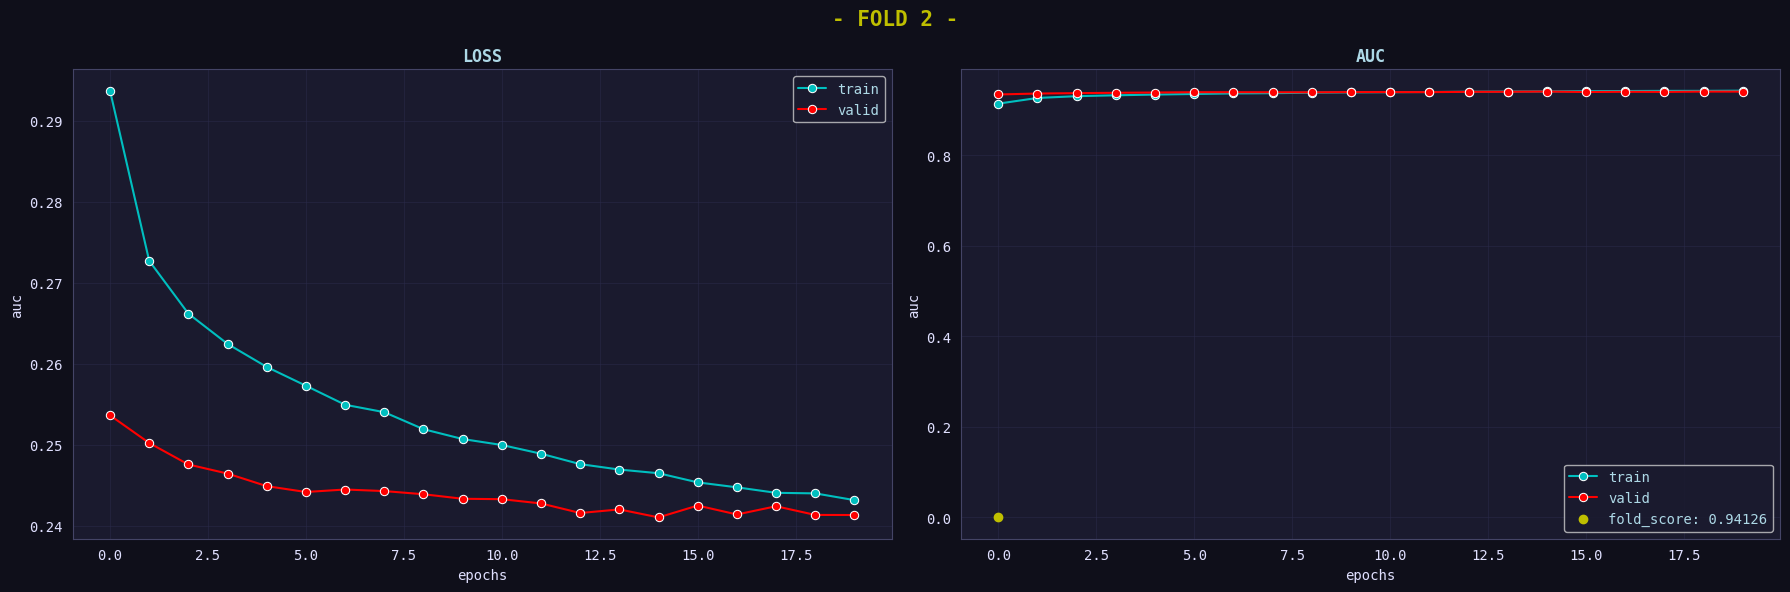

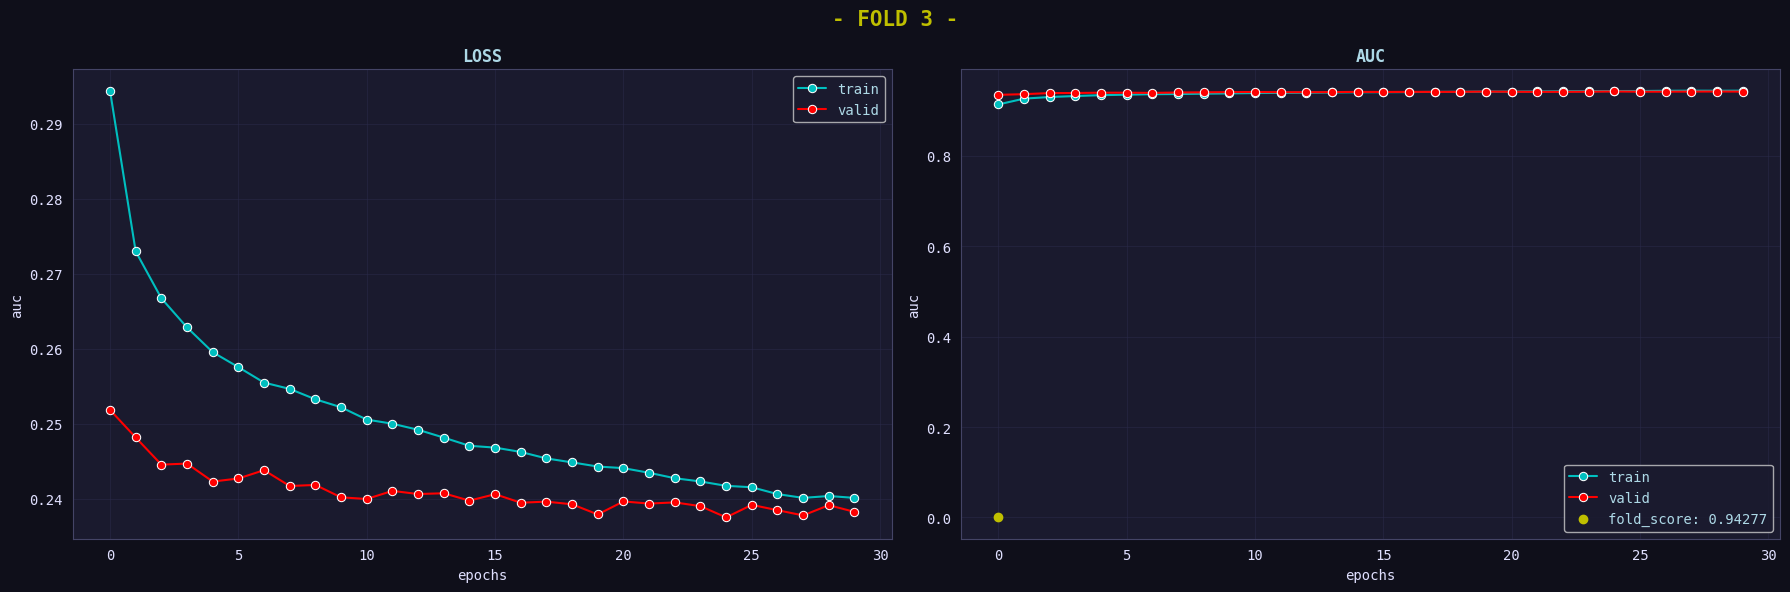

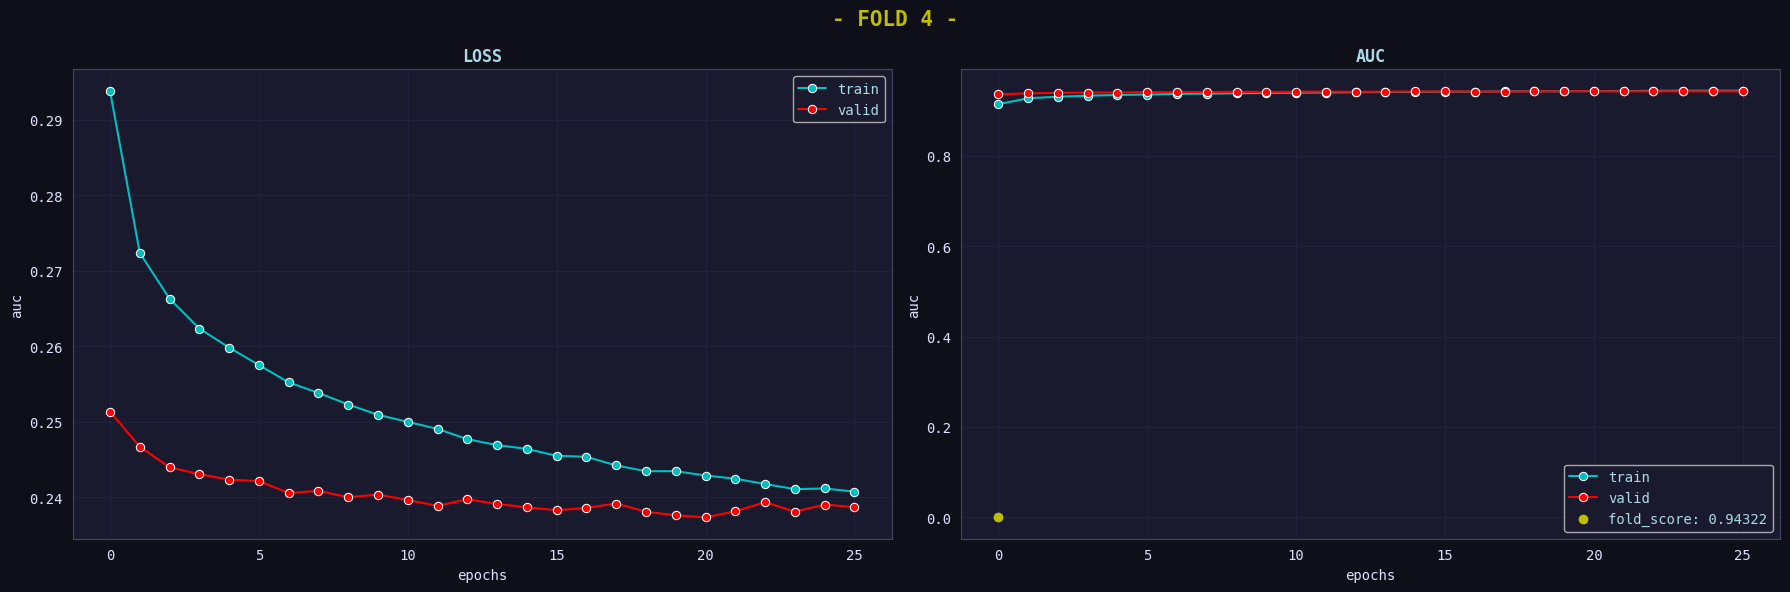

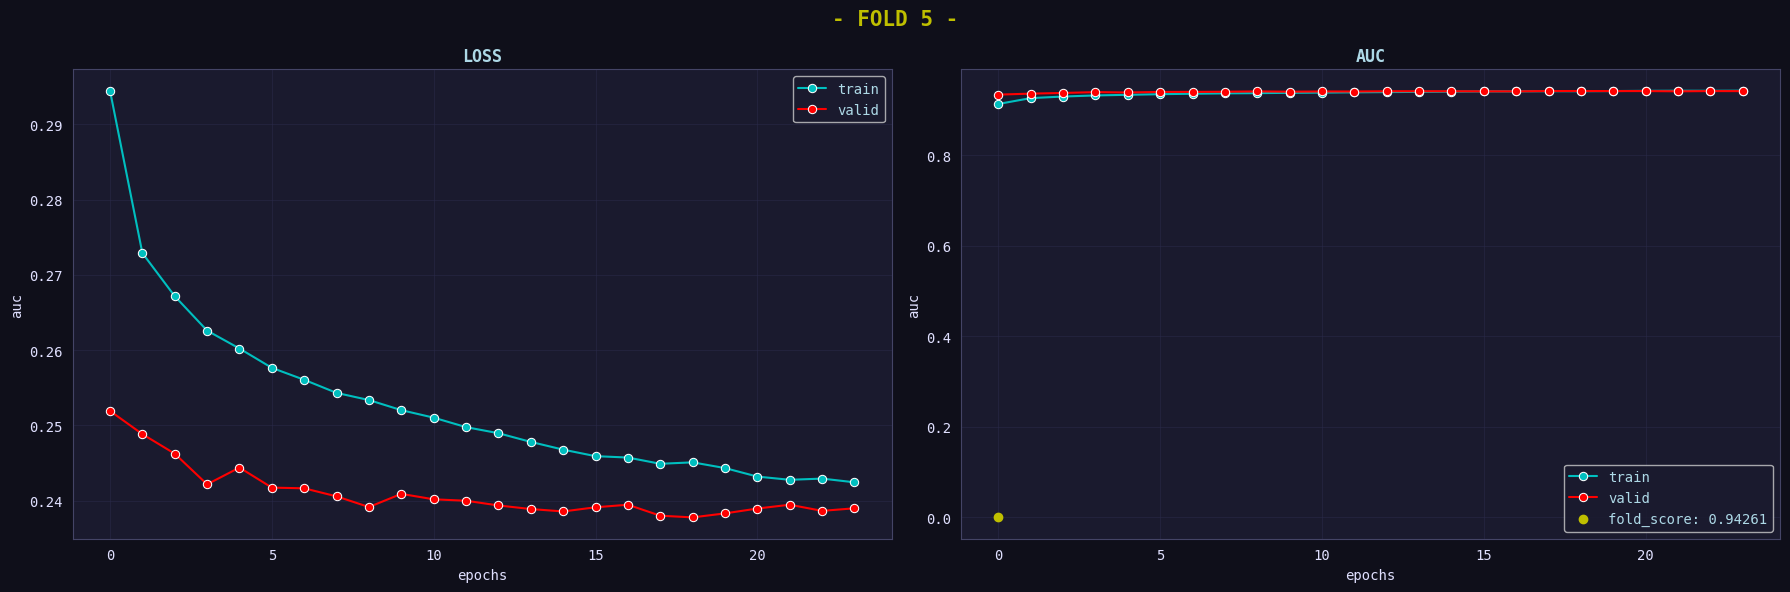

In [48]:
plot_results(result['history'])

Submission saved as: 'submit_scikeras_orig_94244.csv'


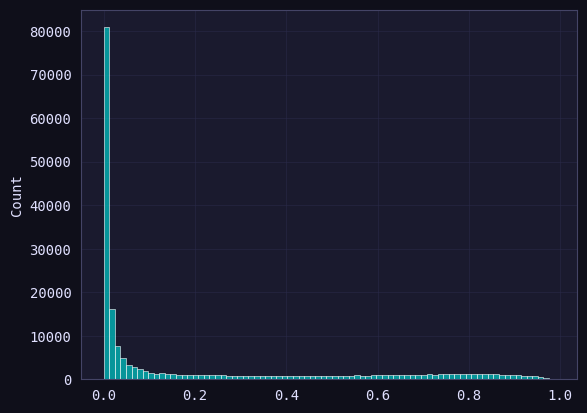

,id,PitNextLap
0,439140,0.006626
1,439141,0.075765
2,439142,0.007542
3,439143,0.383561
4,439144,0.897581
5,439145,0.106446
6,439146,0.001038
7,439147,0.001678
8,439148,0.039587
9,439149,0.000801


In [49]:
n = version_name + str(np.round(np.mean(result['final_score']), 5)).split('.')[1]

np.save(f'oof_{n}.npy', result['oof_preds'])
np.save(f'test_{n}.npy', result['test_preds'])

submit[TARGET] = result['test_preds'].ravel()
submit.to_csv(f"submit_{n}.csv", index=False)

print(f"Submission saved as: 'submit_{n}.csv'")

sns.histplot(submit[TARGET].values)
plt.show()

submit.head(10)

In [50]:
# ## -- PLOTTING RESULTS --
# histories = result['history']

# for i, data in tqdm(enumerate(histories), total=len(histories)):
#     loss_results = pd.DataFrame({'train_loss': data['loss'], 'val_loss': data['val_loss']})
#     auc_results = pd.DataFrame({'train_auc': data['auc'], 'val_auc': data['val_auc']})
#     plt.figure(figsize=(16, 5))
#     marker = 'o'

#     ## -- PLOT LOSS --
#     plt.subplot(121)
#     sns.lineplot(loss_results, x=loss_results.index, y=loss_results.train_loss, label='train_loss', marker=marker)
#     sns.lineplot(loss_results, x=loss_results.index, y=loss_results.val_loss, label='val_loss', marker=marker)
#     plt.title('LOSS', fontweight='semibold')
#     plt.xlabel('Epochs')
#     plt.ylabel('Loss')

#     ## -- PLOT AUC --
#     plt.subplot(122)
#     sns.lineplot(auc_results, x=auc_results.index, y=auc_results.train_auc, label='train_auc', marker=marker)
#     sns.lineplot(auc_results, x=auc_results.index, y=auc_results.val_auc, label='val_auc', marker=marker)
#     plt.title('ROC-AUC', fontweight='semibold')
#     plt.xlabel('Epochs')
#     plt.ylabel('AUC')

#     stat_ = f"fold_auc: {result['fold_score'][i]:.5f}"
#     plt.scatter(x=0, y=0, label=stat_, color='y')

#     plt.suptitle(f"FOLD {i+1}", fontsize=16, fontweight='semibold')
#     plt.legend(loc='best')
#     plt.tight_layout()
#     plt.show()
#     print()